# Parking Lot IP Scaling Tests: Assignment Strategy Comparison

This notebook compares three assignment strategies:

1. `random`
2. `nearest`
3. `furthest`

For each assignment method, the model:

1. Builds a parameterized parking-lot graph.
2. Generates one car per parking spot.
3. Assigns cars to spots using the selected method.
4. Computes fixed NetworkX shortest paths.
5. Solves an IP that schedules movement along those fixed paths.
6. Enforces edge capacities.
7. Adds parking duration and adjacent-aisle blocking.
8. Minimizes makespan.

Animation cells are removed.

Important runtime behavior:

- Each full instance gets a cutoff controlled by `INSTANCE_TIME_LIMIT_SECONDS`.
- The cutoff includes graph building, car generation, shortest paths, IP construction, and IP solve.
- If a method hits the cutoff for a row value, that method stops and does not try larger row values.
- A print statement appears after each completed row/method run.


In [2]:
import time
import random

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import gurobipy as gp
from gurobipy import GRB


## 1. Parking-lot graph construction

In [3]:
def build_parking_lot_graph(
    num_rows,
    row_spacing=3.0,
    col_spacing=8.0,
    spot_offset=2.0,
    middle_spot_offset=1.2,
    top_bottom_capacity=3,
    normal_aisle_capacity=1,
    top_bottom_travel_time=3,
    normal_aisle_travel_time=1,
    parking_duration=3,
):
    if num_rows < 3:
        raise ValueError("num_rows must be at least 3.")

    expected_num_spots = (num_rows - 2) * 4

    G = nx.DiGraph()
    pos = {}

    left_col_x = 0
    right_col_x = col_spacing

    for r in range(num_rows):
        y = -r * row_spacing
        left_node = f"L{r}"
        right_node = f"R{r}"

        pos[left_node] = (left_col_x, y)
        pos[right_node] = (right_col_x, y)

        G.add_node(left_node, kind="intersection")
        G.add_node(right_node, kind="intersection")

        if r == 0 or r == num_rows - 1:
            G.add_edge(
                left_node, right_node,
                travel_time=top_bottom_travel_time,
                capacity=top_bottom_capacity,
                edge_type="aisle",
            )
            G.add_edge(
                right_node, left_node,
                travel_time=top_bottom_travel_time,
                capacity=top_bottom_capacity,
                edge_type="aisle",
            )

    for r in range(num_rows - 1):
        G.add_edge(
            f"L{r}", f"L{r+1}",
            travel_time=normal_aisle_travel_time,
            capacity=normal_aisle_capacity,
            edge_type="aisle",
        )
        G.add_edge(
            f"L{r+1}", f"L{r}",
            travel_time=normal_aisle_travel_time,
            capacity=normal_aisle_capacity,
            edge_type="aisle",
        )

        G.add_edge(
            f"R{r}", f"R{r+1}",
            travel_time=normal_aisle_travel_time,
            capacity=normal_aisle_capacity,
            edge_type="aisle",
        )
        G.add_edge(
            f"R{r+1}", f"R{r}",
            travel_time=normal_aisle_travel_time,
            capacity=normal_aisle_capacity,
            edge_type="aisle",
        )

    entrances = ["E1", "E2"]

    pos["E1"] = (left_col_x, row_spacing)
    pos["E2"] = (right_col_x, -num_rows * row_spacing)

    G.add_node("E1", kind="entrance")
    G.add_node("E2", kind="entrance")

    G.add_edge("E1", "L0", travel_time=1, capacity=top_bottom_capacity, edge_type="aisle")
    G.add_edge("E2", f"R{num_rows - 1}", travel_time=1, capacity=top_bottom_capacity, edge_type="aisle")

    spot_count = 1

    for r in range(num_rows):
        if r == 0 or r == num_rows - 1:
            continue

        y = -r * row_spacing

        spot_specs = [
            (f"L{r}", left_col_x - spot_offset, y),
            (f"L{r}", left_col_x + spot_offset, y + middle_spot_offset),
            (f"R{r}", right_col_x - spot_offset, y - middle_spot_offset),
            (f"R{r}", right_col_x + spot_offset, y),
        ]

        for aisle_node, x_pos, y_pos in spot_specs:
            spot = f"S{spot_count}"
            spot_count += 1

            pos[spot] = (x_pos, y_pos)
            G.add_node(spot, kind="spot")

            G.add_edge(
                aisle_node, spot,
                travel_time=parking_duration,
                capacity=1,
                edge_type="parking",
            )
            G.add_edge(
                spot, aisle_node,
                travel_time=1,
                capacity=1,
                edge_type="spot",
            )

    parking_spots = [
        node for node, data in G.nodes(data=True)
        if data.get("kind") == "spot"
    ]

    if len(parking_spots) != expected_num_spots:
        raise ValueError(
            f"Expected {expected_num_spots} spots, generated {len(parking_spots)}."
        )

    return G, pos, parking_spots, entrances


## 2. Arrival generation and assignment methods

In [4]:
def generate_poisson_arrival_times(
    num_cars,
    total_time=30,
    base_rate=0.40,
    peak_rate=2.20,
    peak_time=18,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    arrival_times = []

    for t in range(total_time):
        if t <= peak_time:
            rate = base_rate + (peak_rate - base_rate) * (t / peak_time)
        else:
            rate = peak_rate * max(
                0.15,
                1 - (t - peak_time) / max(1, total_time - peak_time),
            )

        arrivals_this_step = rng.poisson(rate)

        for _ in range(arrivals_this_step):
            arrival_times.append(t)

        if len(arrival_times) >= num_cars:
            break

    if len(arrival_times) == 0:
        arrival_times.append(0)

    while len(arrival_times) < num_cars:
        arrival_times.append(arrival_times[-1] + rng.poisson(1) + 1)

    return arrival_times[:num_cars]


def car_number(car):
    return int(car["name"].split()[-1])


def spot_row(spot):
    """
    Convert spot name S1, S2, ... into its parking row.

    There are 4 spots per interior row:
        row 1: S1-S4
        row 2: S5-S8
        row 3: S9-S12
        etc.
    """
    spot_index = int(spot[1:])
    return ((spot_index - 1) // 4) + 1


def spot_side(spot):
    """
    Determine which aisle side a spot belongs to.

    For each parking row:
        S(4r-3), S(4r-2) are attached to the left aisle Lr
        S(4r-1), S(4r)   are attached to the right aisle Rr
    """
    spot_index = int(spot[1:])
    position_in_row = (spot_index - 1) % 4

    if position_in_row in [0, 1]:
        return "L"
    else:
        return "R"


def car_side(car):
    """
    E1 cars use the left aisle.
    E2 cars use the right aisle.
    """
    if car["start"] == "E1":
        return "L"
    elif car["start"] == "E2":
        return "R"
    else:
        raise ValueError(f"Unknown car entrance: {car['start']}")


def assign_random_spots(cars, parking_spots, random_state, G=None):
    chosen_spots = random_state.sample(parking_spots, len(cars))

    for car, spot in zip(cars, chosen_spots):
        car["spot"] = spot

    return cars


def assign_nearest_spots(cars, parking_spots, random_state=None, G=None):
    """
    Greedy nearest-available assignment.

    Cars are processed in arrival order. Each car chooses the closest available
    spot on its own aisle side:
        E1 cars choose from left-side spots.
        E2 cars choose from right-side spots.

    This avoids crossing over aisles during assignment.
    """
    available_spots = set(parking_spots)
    cars_sorted = sorted(cars, key=lambda car: (car["start_time"], car_number(car)))

    for car in cars_sorted:
        side = car_side(car)

        candidate_spots = [
            spot for spot in available_spots
            if spot_side(spot) == side
        ]

        if len(candidate_spots) == 0:
            # Fallback should rarely be needed unless one side runs out.
            candidate_spots = list(available_spots)

        best_spot = min(candidate_spots, key=spot_row)

        car["spot"] = best_spot
        available_spots.remove(best_spot)

    return cars


def assign_furthest_spots(cars, parking_spots, random_state=None, G=None):
    """
    Greedy furthest-available assignment.

    Cars are processed in arrival order. Each car chooses the furthest available
    spot on its own aisle side:
        E1 cars choose from left-side spots.
        E2 cars choose from right-side spots.

    This approximates back-to-front filling and avoids crossing over aisles.
    """
    available_spots = set(parking_spots)
    cars_sorted = sorted(cars, key=lambda car: (car["start_time"], car_number(car)))

    for car in cars_sorted:
        side = car_side(car)

        candidate_spots = [
            spot for spot in available_spots
            if spot_side(spot) == side
        ]

        if len(candidate_spots) == 0:
            # Fallback should rarely be needed unless one side runs out.
            candidate_spots = list(available_spots)

        best_spot = max(candidate_spots, key=spot_row)

        car["spot"] = best_spot
        available_spots.remove(best_spot)

    return cars


ASSIGNMENT_FUNCTIONS = {
    "random": assign_random_spots,
    "nearest": assign_nearest_spots,
    "furthest": assign_furthest_spots,
}


In [5]:
def create_cars_for_lot(
    G,
    parking_spots,
    entrances,
    seed=42,
    assignment_method="random",
):
    rng = np.random.default_rng(seed)
    random_state = random.Random(seed)

    num_cars = len(parking_spots)
    arrival_times = generate_poisson_arrival_times(num_cars, rng=rng)

    cars = []

    for i in range(num_cars):
        cars.append({
            "name": f"car {i + 1}",
            "start": entrances[i % len(entrances)],
            "start_time": arrival_times[i],
            "spot": None,
            "path": None,
            "path_edges": None,
            "travel_time": None,
        })

    if assignment_method not in ASSIGNMENT_FUNCTIONS:
        raise ValueError(f"Unknown assignment method: {assignment_method}")

    cars = ASSIGNMENT_FUNCTIONS[assignment_method](
        cars=cars,
        parking_spots=parking_spots,
        random_state=random_state,
        G=G,
    )

    for car in cars:
        if not nx.has_path(G, car["start"], car["spot"]):
            raise ValueError(f"No path from {car['start']} to {car['spot']}.")

        car["path"] = nx.shortest_path(
            G,
            source=car["start"],
            target=car["spot"],
            weight="travel_time",
        )

        car["path_edges"] = list(zip(car["path"][:-1], car["path"][1:]))

        car["travel_time"] = nx.shortest_path_length(
            G,
            source=car["start"],
            target=car["spot"],
            weight="travel_time",
        )

    return cars


## 3. IP helper functions

In [6]:
def edge_duration(G, edge):
    u, v = edge
    return int(G[u][v].get("travel_time", 1))


def is_parking_edge(G, edge):
    u, v = edge
    return G.nodes[v].get("kind") == "spot"


def parking_aisle_node(G, edge):
    u, v = edge
    return u if is_parking_edge(G, edge) else None


def movement_uses_node(edge, node):
    u, v = edge
    return u == node or v == node


## 4. Fixed-path IP solver with full-instance timeout

The timeout includes graph building, car generation, shortest paths, IP construction, and IP solving.

`Constraint 7` is not just a sanity check. It defines the makespan by forcing makespan to be at least every car's finish time.


In [7]:
def timeout_result(status, elapsed_time, model=None, T=np.nan):
    return {
        "status_code": None,
        "status": status,
        "solver_runtime": 0.0,
        "wall_runtime": elapsed_time,
        "num_vars": np.nan if model is None else model.NumVars,
        "num_constraints": np.nan if model is None else model.NumConstrs,
        "time_horizon": T,
        "has_solution": False,
        "makespan": np.nan,
        "avg_wait_time": np.nan,
        "total_wait_time": np.nan,
        "max_wait_time": np.nan,
        "mip_gap": np.nan,
    }


def solve_fixed_path_ip(
    G,
    cars,
    instance_start_time,
    instance_time_limit_seconds=300,
    mip_gap=None,
    output_flag=0,
):
    def elapsed():
        return time.time() - instance_start_time

    def remaining_time():
        return instance_time_limit_seconds - elapsed()

    def timed_out():
        return remaining_time() <= 0

    if timed_out():
        return timeout_result("INSTANCE_TIMEOUT", elapsed())

    num_cars = len(cars)
    max_arrival_time = max(car["start_time"] for car in cars)

    max_path_duration = max(
        sum(edge_duration(G, edge) for edge in car["path_edges"])
        for car in cars
    )

    max_parking_duration = max(
        edge_duration(G, edge)
        for car in cars
        for edge in car["path_edges"]
        if is_parking_edge(G, edge)
    )

    T = max_arrival_time + (num_cars * max_parking_duration) + max_path_duration + 20
    time_steps = range(T)

    model = gp.Model("fixed_path_congestion_with_parking_blocking")
    model.Params.OutputFlag = output_flag

    if mip_gap is not None:
        model.Params.MIPGap = mip_gap

    x = {}

    # Decision variables
    for c, car in enumerate(cars):
        if timed_out():
            return timeout_result("INSTANCE_TIMEOUT", elapsed(), model, T)

        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            for t in range(T - dur + 1):
                x[c, k, t] = model.addVar(
                    vtype=GRB.BINARY,
                    name=f"x_car{c}_step{k}_time{t}",
                )

    finish_time = {
        c: model.addVar(vtype=GRB.INTEGER, lb=0, ub=T, name=f"finish_time_car{c}")
        for c in range(num_cars)
    }

    makespan = model.addVar(vtype=GRB.INTEGER, lb=0, ub=T, name="makespan")
    model.update()

    # Constraint 1: each path step exactly once
    for c, car in enumerate(cars):
        if timed_out():
            return timeout_result("INSTANCE_TIMEOUT", elapsed(), model, T)

        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            model.addConstr(
                gp.quicksum(x[c, k, t] for t in range(T - dur + 1)) == 1,
                name=f"car{c}_step{k}_once",
            )

    # Constraint 2: no movement before arrival
    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            for t in range(min(car["start_time"], T - dur + 1)):
                model.addConstr(
                    x[c, k, t] == 0,
                    name=f"car{c}_step{k}_before_arrival_t{t}",
                )

    # Constraint 3: path order
    for c, car in enumerate(cars):
        for k in range(len(car["path_edges"]) - 1):
            edge_k = car["path_edges"][k]
            edge_next = car["path_edges"][k + 1]

            dur_k = edge_duration(G, edge_k)
            dur_next = edge_duration(G, edge_next)

            start_k = gp.quicksum(
                t * x[c, k, t]
                for t in range(T - dur_k + 1)
            )

            start_next = gp.quicksum(
                t * x[c, k + 1, t]
                for t in range(T - dur_next + 1)
            )

            model.addConstr(
                start_next >= start_k + dur_k,
                name=f"car{c}_step_order_{k}",
            )

    # Constraint 4: edge capacities
    for u, v, data in G.edges(data=True):
        if timed_out():
            return timeout_result("INSTANCE_TIMEOUT", elapsed(), model, T)

        edge = (u, v)
        capacity = data.get("capacity", 1)

        for tau in time_steps:
            active_on_edge = []

            for c, car in enumerate(cars):
                for k, path_edge in enumerate(car["path_edges"]):
                    if path_edge != edge:
                        continue

                    dur = edge_duration(G, path_edge)

                    for t in range(
                        max(0, tau - dur + 1),
                        min(tau + 1, T - dur + 1),
                    ):
                        active_on_edge.append(x[c, k, t])

            if active_on_edge:
                model.addConstr(
                    gp.quicksum(active_on_edge) <= capacity,
                    name=f"edge_capacity_{u}_{v}_time{tau}",
                )

    # Constraint 5: parking blocks adjacent aisle node
    aisle_nodes = [
        node for node, data in G.nodes(data=True)
        if data.get("kind") == "intersection"
    ]

    big_M = num_cars

    for aisle_node in aisle_nodes:
        if timed_out():
            return timeout_result("INSTANCE_TIMEOUT", elapsed(), model, T)

        for tau in time_steps:
            active_parking_at_node = []
            active_nonparking_through_node = []

            for c, car in enumerate(cars):
                for k, edge in enumerate(car["path_edges"]):
                    dur = edge_duration(G, edge)

                    for t in range(
                        max(0, tau - dur + 1),
                        min(tau + 1, T - dur + 1),
                    ):
                        if is_parking_edge(G, edge) and parking_aisle_node(G, edge) == aisle_node:
                            active_parking_at_node.append(x[c, k, t])
                        elif not is_parking_edge(G, edge) and movement_uses_node(edge, aisle_node):
                            active_nonparking_through_node.append(x[c, k, t])

            if active_parking_at_node:
                model.addConstr(
                    gp.quicksum(active_parking_at_node) <= 1,
                    name=f"one_parking_at_{aisle_node}_time{tau}",
                )

            if active_parking_at_node and active_nonparking_through_node:
                model.addConstr(
                    gp.quicksum(active_nonparking_through_node)
                    + big_M * gp.quicksum(active_parking_at_node)
                    <= big_M,
                    name=f"parking_blocks_{aisle_node}_time{tau}",
                )

    # Constraint 6: finish time definition
    for c, car in enumerate(cars):
        last_step = len(car["path_edges"]) - 1
        final_edge = car["path_edges"][last_step]
        final_duration = edge_duration(G, final_edge)

        final_start = gp.quicksum(
            t * x[c, last_step, t]
            for t in range(T - final_duration + 1)
        )

        model.addConstr(
            finish_time[c] == final_start + final_duration,
            name=f"finish_time_def_car{c}",
        )

    # Constraint 7: makespan definition
    for c in range(num_cars):
        model.addConstr(
            makespan >= finish_time[c],
            name=f"makespan_after_car{c}",
        )

    model.setObjective(makespan, GRB.MINIMIZE)

    # Give Gurobi only the remaining instance time.
    model.Params.TimeLimit = max(1.0, remaining_time())
    model.optimize()

    status_text = {
        GRB.OPTIMAL: "OPTIMAL",
        GRB.TIME_LIMIT: "TIME_LIMIT",
        GRB.INFEASIBLE: "INFEASIBLE",
        GRB.INF_OR_UNBD: "INF_OR_UNBD",
        GRB.UNBOUNDED: "UNBOUNDED",
    }.get(model.status, str(model.status))

    result = {
        "status_code": model.status,
        "status": status_text,
        "solver_runtime": model.Runtime,
        "wall_runtime": elapsed(),
        "num_vars": model.NumVars,
        "num_constraints": model.NumConstrs,
        "time_horizon": T,
        "has_solution": model.SolCount > 0,
        "makespan": np.nan,
        "avg_wait_time": np.nan,
        "total_wait_time": np.nan,
        "max_wait_time": np.nan,
        "mip_gap": np.nan,
    }

    if model.SolCount > 0:
        wait_times = []

        for c, car in enumerate(cars):
            minimum_possible_time = sum(
                edge_duration(G, edge)
                for edge in car["path_edges"]
            )

            car_finish = int(round(finish_time[c].X))
            wait_times.append(
                car_finish - car["start_time"] - minimum_possible_time
            )

        result["makespan"] = int(round(makespan.X))
        result["avg_wait_time"] = float(np.mean(wait_times))
        result["total_wait_time"] = float(np.sum(wait_times))
        result["max_wait_time"] = float(np.max(wait_times))

        try:
            result["mip_gap"] = model.MIPGap
        except gp.GurobiError:
            pass

    if result["wall_runtime"] >= 0.99 * instance_time_limit_seconds:
        if result["status"] not in ["OPTIMAL", "INFEASIBLE"]:
            result["status"] = "INSTANCE_TIMEOUT"

    return result


## 5. Scaling experiment across assignment methods

The row list is:

```python
row_values = [8, 12, 16, 20, 24, 32, 40]
```


In [8]:
def run_scaling_experiment(
    row_values,
    assignment_methods=("random", "nearest", "furthest"),
    seed=42,
    instance_time_limit_seconds=1000,
    mip_gap=None,
    stop_after_time_limit=True,
):
    records = []

    for assignment_method in assignment_methods:
        print(f"\n=== Assignment method: {assignment_method} ===")

        for num_rows in row_values:
            instance_start = time.time()

            G, pos, parking_spots, entrances = build_parking_lot_graph(num_rows)

            cars = create_cars_for_lot(
                G,
                parking_spots,
                entrances,
                seed=seed,
                assignment_method=assignment_method,
            )

            if time.time() - instance_start >= instance_time_limit_seconds:
                result = timeout_result(
                    status="INSTANCE_TIMEOUT",
                    elapsed_time=time.time() - instance_start,
                )
            else:
                result = solve_fixed_path_ip(
                    G,
                    cars,
                    instance_start_time=instance_start,
                    instance_time_limit_seconds=instance_time_limit_seconds,
                    mip_gap=mip_gap,
                    output_flag=0,
                )

            record = {
                "num_rows": num_rows,
                "num_spots": len(parking_spots),
                "num_cars": len(cars),
                "assignment_method": assignment_method,
                **result,
            }

            records.append(record)

            print(
                f"Finished num_rows={num_rows}, "
                f"method={assignment_method}, "
                f"status={result['status']}, "
                f"instance_time={result['wall_runtime']:.1f}s, "
                f"ip_time={result['solver_runtime']:.1f}s, "
                f"makespan={result['makespan']}"
            )

            hit_time_limit = (
                result["status"] in ["TIME_LIMIT", "INSTANCE_TIMEOUT"]
                or result["wall_runtime"] >= 0.99 * instance_time_limit_seconds
            )

            if stop_after_time_limit and hit_time_limit:
                print(
                    f"Stopping {assignment_method} after num_rows={num_rows} "
                    f"because it hit the time limit."
                )
                break

    return pd.DataFrame(records)


row_values = [8, 12, 16, 20, 24, 32, 40]

# Change this one variable to adjust the full-instance cutoff.
INSTANCE_TIME_LIMIT_SECONDS = 1000

results_df = run_scaling_experiment(
    row_values=row_values,
    assignment_methods=("random", "nearest", "furthest"),
    seed=42,
    instance_time_limit_seconds=INSTANCE_TIME_LIMIT_SECONDS,
    mip_gap=None,
    stop_after_time_limit=True,
)

results_df



=== Assignment method: random ===
Set parameter Username
Set parameter LicenseID to value 2768089
Academic license - for non-commercial use only - expires 2027-01-20
Finished num_rows=8, method=random, status=OPTIMAL, instance_time=1.0s, ip_time=0.4s, makespan=27
Finished num_rows=12, method=random, status=OPTIMAL, instance_time=5.3s, ip_time=2.1s, makespan=39
Finished num_rows=16, method=random, status=OPTIMAL, instance_time=16.8s, ip_time=7.8s, makespan=59
Finished num_rows=20, method=random, status=OPTIMAL, instance_time=42.9s, ip_time=19.5s, makespan=95
Finished num_rows=24, method=random, status=OPTIMAL, instance_time=169.1s, ip_time=67.5s, makespan=133
Finished num_rows=32, method=random, status=INSTANCE_TIMEOUT, instance_time=302.3s, ip_time=0.0s, makespan=nan
Stopping random after num_rows=32 because it hit the time limit.

=== Assignment method: nearest ===
Finished num_rows=8, method=nearest, status=OPTIMAL, instance_time=2.8s, ip_time=0.7s, makespan=28
Finished num_rows=12,

,num_rows,num_spots,num_cars,assignment_method,status_code,status,solver_runtime,wall_runtime,num_vars,num_constraints,time_horizon,has_solution,makespan,avg_wait_time,total_wait_time,max_wait_time,mip_gap
0,8,24,24,random,2.0,OPTIMAL,0.371,1.044047,16167,10547,121,True,27.0,3.458333,83.0,11.0,0.0
1,12,40,40,random,2.0,OPTIMAL,2.149,5.324601,60371,27179,181,True,39.0,8.775000,351.0,30.0,0.0
2,16,56,56,random,2.0,OPTIMAL,7.816,16.829763,137653,55226,257,True,59.0,13.553571,759.0,40.0,0.0
3,20,72,72,random,2.0,OPTIMAL,19.458,42.857875,300137,102309,342,True,95.0,22.291667,1605.0,82.0,0.0
4,24,88,88,random,2.0,OPTIMAL,67.507,169.118805,510517,165886,427,True,133.0,4.045455,356.0,23.0,0.0
5,32,120,120,random,NaN,INSTANCE_TIMEOUT,0.000,302.265109,1289281,0,597,False,NaN,NaN,NaN,NaN,NaN
6,8,24,24,nearest,2.0,OPTIMAL,0.733,2.751066,15553,8651,118,True,28.0,5.458333,131.0,16.0,0.0
7,12,40,40,nearest,2.0,OPTIMAL,5.257,13.476785,53361,22528,178,True,40.0,11.100000,444.0,29.0,0.0
8,16,56,56,nearest,2.0,OPTIMAL,12.485,35.630271,135073,47258,254,True,64.0,18.000000,1008.0,52.0,0.0
9,20,72,72,nearest,2.0,OPTIMAL,36.100,96.225731,280621,87665,339,True,102.0,30.402778,2189.0,97.0,0.0


## 6. Individual comparison plots

In [9]:
def plot_metric_by_method(
    results_df,
    metric,
    ylabel,
    title,
    cutoff_line=None,
):
    plt.figure(figsize=(8, 5))

    for method, group in results_df.groupby("assignment_method"):
        group = group.sort_values("num_spots")

        plt.plot(
            group["num_spots"],
            group[metric],
            marker="o",
            label=method,
        )

    if cutoff_line is not None:
        plt.axhline(
            cutoff_line,
            linestyle="--",
            label=f"{cutoff_line}s cutoff",
        )

    plt.xlabel("Number of cars/spots")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


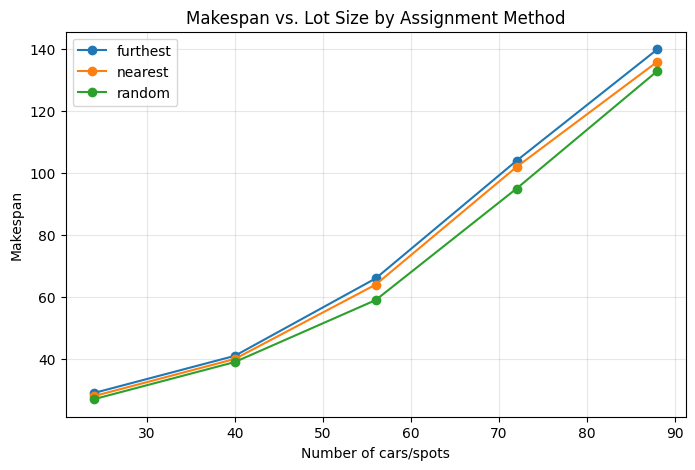

In [10]:
plot_metric_by_method(
    results_df,
    metric="makespan",
    ylabel="Makespan",
    title="Makespan vs. Lot Size by Assignment Method",
)


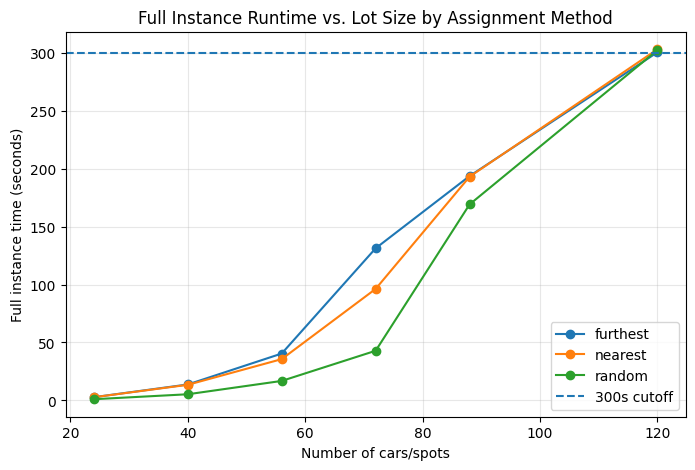

In [11]:
plot_metric_by_method(
    results_df,
    metric="wall_runtime",
    ylabel="Full instance time (seconds)",
    title="Full Instance Runtime vs. Lot Size by Assignment Method",
    cutoff_line=INSTANCE_TIME_LIMIT_SECONDS,
)


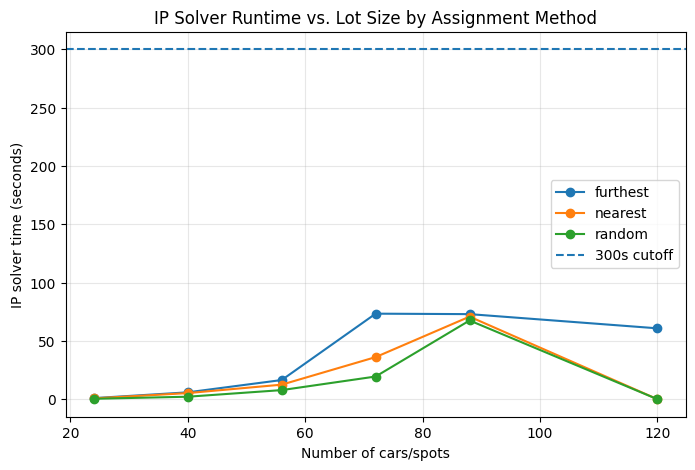

In [12]:
plot_metric_by_method(
    results_df,
    metric="solver_runtime",
    ylabel="IP solver time (seconds)",
    title="IP Solver Runtime vs. Lot Size by Assignment Method",
    cutoff_line=INSTANCE_TIME_LIMIT_SECONDS,
)


## 7. Stacked comparison plot

This creates one figure with three stacked plots:

1. Makespan
2. Full instance time
3. IP solver time


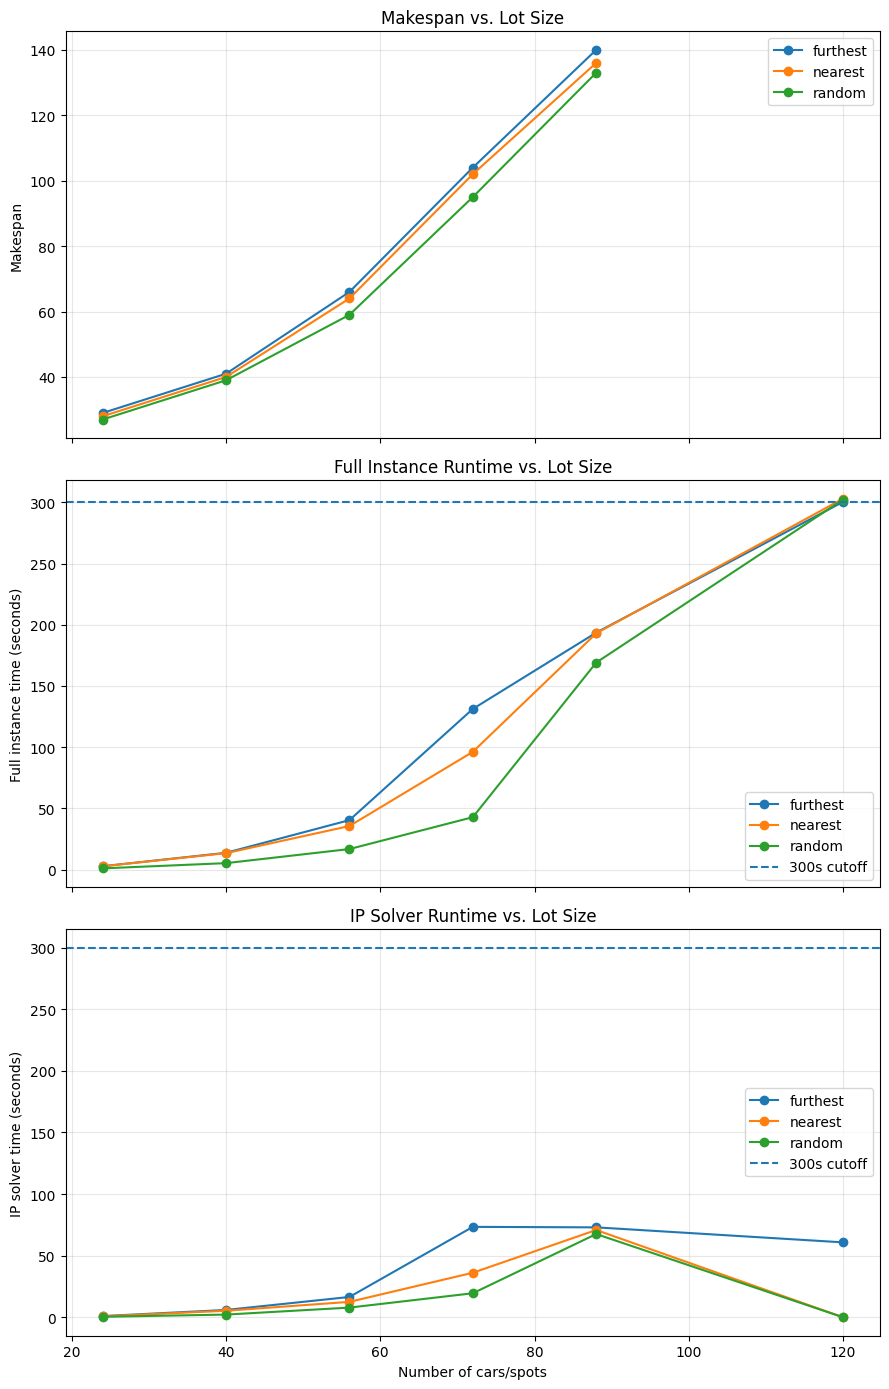

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 14), sharex=True)

plot_specs = [
    ("makespan", "Makespan", "Makespan vs. Lot Size"),
    ("wall_runtime", "Full instance time (seconds)", "Full Instance Runtime vs. Lot Size"),
    ("solver_runtime", "IP solver time (seconds)", "IP Solver Runtime vs. Lot Size"),
]

for ax, (metric, ylabel, title) in zip(axes, plot_specs):
    for method, group in results_df.groupby("assignment_method"):
        group = group.sort_values("num_spots")

        ax.plot(
            group["num_spots"],
            group[metric],
            marker="o",
            label=method,
        )

    if metric in ["wall_runtime", "solver_runtime"]:
        ax.axhline(INSTANCE_TIME_LIMIT_SECONDS, linestyle="--", label=f"{INSTANCE_TIME_LIMIT_SECONDS}s cutoff")

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Number of cars/spots")

plt.tight_layout()
plt.show()


## 8. Save results

In [ ]:
results_df.to_csv("assignment_method_scaling_results.csv", index=False)
results_df
